=== Summary (100 cases) ===
Average posterior probability (true suspects): 1.0000
Average posterior probability (false suspects): 0.0000
Proportion cases where true suspect has the highest posterior: 100.00% (100/100)
Proportion cases where true suspect is top AND posterior > 0.5: 100.00% (100/100)
Average of max posterior per case: 1.0000


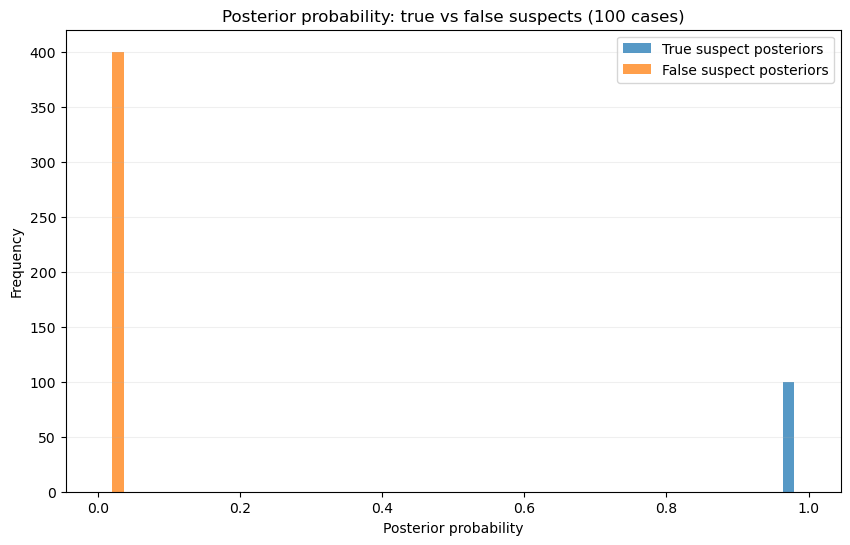

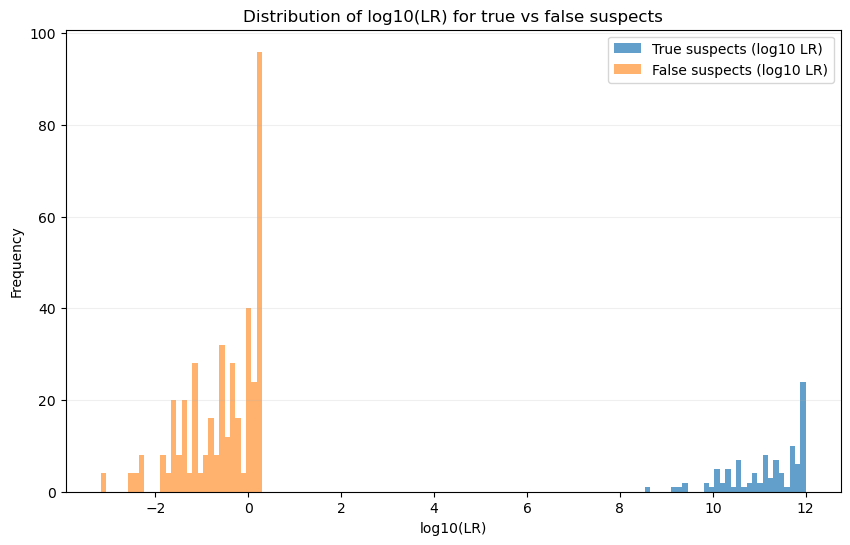

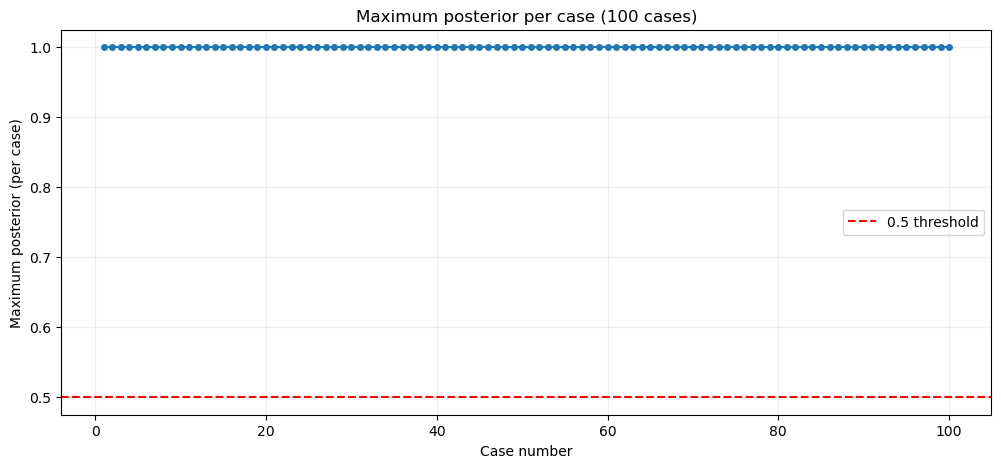

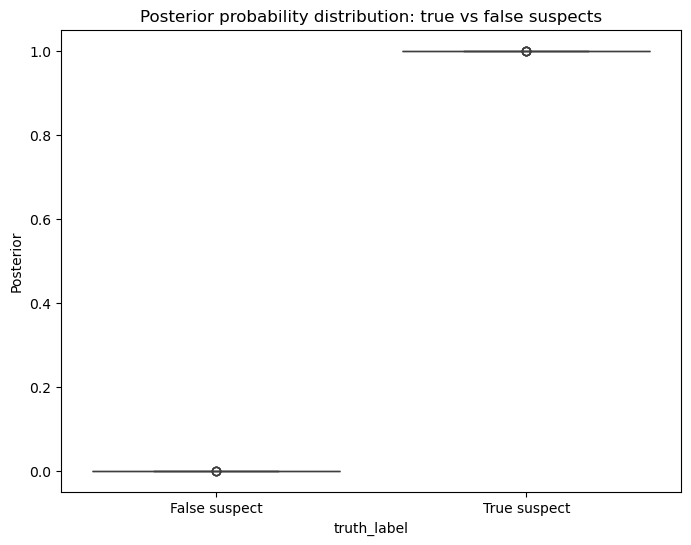

Summary CSV saved: dna_validation_summary_100_cases.csv


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# -----------------------
# Parameters
# -----------------------
num_cases = 100
num_loci = 13
alleles_per_locus = 5
num_suspects = 5
prior_guilt = 1 / num_suspects   # uniform prior
EPS = 1e-12   # tiny value to avoid division by zero

# -----------------------
# Step 1: Simulate allele frequencies
# -----------------------
allele_freqs = [np.random.dirichlet(np.ones(alleles_per_locus)) for _ in range(num_loci)]

def generate_profile():
    """Generate a genetic profile with 2 alleles per locus."""
    profile = []
    for locus in allele_freqs:
        alleles = np.random.choice(range(len(locus)), size=2, p=locus)
        profile.append(tuple(sorted(alleles)))
    return profile

def genotype_prob_from_freqs(genotype, freqs):
    """Return genotype probability under HWE:
       If homozygous: p^2
       If heterozygous: 2pq
    """
    a, b = genotype
    pa = freqs[a]
    pb = freqs[b]
    if a == b:
        return pa * pa
    else:
        return 2 * pa * pb

def profile_rmp(profile, allele_freqs):
    """Random Match Probability for a full multi-locus profile."""
    p = 1.0
    for locus_idx, genotype in enumerate(profile):
        p_loc = genotype_prob_from_freqs(genotype, allele_freqs[locus_idx])
        p *= max(p_loc, EPS)
    return p

# -----------------------
# Step 2: Simulate 100 cases
# -----------------------
records = []
success_count_top_posterior = 0
success_count_top_posterior_thresh = 0
posterior_true_list = []
posterior_false_list = []
max_posterior_per_case = []

for case_id in range(1, num_cases + 1):
    # Generate crime scene (true) profile
    true_profile = generate_profile()

    # Generate suspects and ensure one is the true contributor
    true_suspect_index = np.random.randint(0, num_suspects)
    suspects = []

    for s in range(num_suspects):
        if s == true_suspect_index:
            suspects.append(true_profile.copy())
        else:
            suspects.append(generate_profile())

    # Compute RMP for the crime scene profile
    rmp_true_profile = profile_rmp(true_profile, allele_freqs)

    # Compute LR for each suspect
    LR_list = []
    for s_idx, s_profile in enumerate(suspects):
        match = (s_profile == true_profile)

        # simplified likelihood model
        p_e_given_guilt = 1.0 if match else EPS
        p_e_given_innocent = rmp_true_profile

        lr = (p_e_given_guilt + EPS) / (p_e_given_innocent + EPS)
        LR_list.append(lr)

    # Bayesian posterior
    LR_array = np.array(LR_list, dtype=float)
    numerators = LR_array * prior_guilt
    denominator = numerators.sum()

    if denominator <= 0:
        posterior_array = np.ones_like(numerators) / len(numerators)
    else:
        posterior_array = numerators / denominator

    # Store results
    for s_idx in range(num_suspects):
        records.append({
            "case_id": case_id,
            "suspect_idx": s_idx,
            "is_true_suspect": (s_idx == true_suspect_index),
            "LR": LR_list[s_idx],
            "posterior": posterior_array[s_idx],
            "rmp_evidence": rmp_true_profile
        })

    # Case-level metrics
    max_idx = np.argmax(posterior_array)
    max_post = posterior_array[max_idx]
    max_posterior_per_case.append(max_post)

    if max_idx == true_suspect_index:
        success_count_top_posterior += 1
    if (max_idx == true_suspect_index) and (posterior_array[true_suspect_index] > 0.5):
        success_count_top_posterior_thresh += 1

    posterior_true_list.append(posterior_array[true_suspect_index])

    for i in range(num_suspects):
        if i != true_suspect_index:
            posterior_false_list.append(posterior_array[i])

# -----------------------
# Step 3: Results summary
# -----------------------
df_results = pd.DataFrame.from_records(records)

avg_post_true = np.mean(posterior_true_list)
avg_post_false = np.mean(posterior_false_list)
prop_true_top = success_count_top_posterior / num_cases
prop_true_top_thresh = success_count_top_posterior_thresh / num_cases
avg_max_post = np.mean(max_posterior_per_case)

print("=== Summary (100 cases) ===")
print(f"Average posterior probability (true suspects): {avg_post_true:.4f}")
print(f"Average posterior probability (false suspects): {avg_post_false:.4f}")
print(f"Proportion cases where true suspect has the highest posterior: {prop_true_top:.2%} ({success_count_top_posterior}/{num_cases})")
print(f"Proportion cases where true suspect is top AND posterior > 0.5: {prop_true_top_thresh:.2%} ({success_count_top_posterior_thresh}/{num_cases})")
print(f"Average of max posterior per case: {avg_max_post:.4f}")
print("===========================")

# -----------------------
# Step 4: Visualizations
# -----------------------
plt.figure(figsize=(10,6))
plt.hist(
    [posterior_true_list, posterior_false_list],
    bins=25,
    label=["True suspect posteriors", "False suspect posteriors"],
    stacked=False,
    alpha=0.75
)
plt.xlabel("Posterior probability")
plt.ylabel("Frequency")
plt.title("Posterior probability: true vs false suspects (100 cases)")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.show()

df_results["log10_LR"] = np.log10(df_results["LR"] + EPS)
plt.figure(figsize=(10,6))
plt.hist(df_results[df_results["is_true_suspect"] == True]["log10_LR"], bins=30, alpha=0.7, label="True suspects (log10 LR)")
plt.hist(df_results[df_results["is_true_suspect"] == False]["log10_LR"], bins=30, alpha=0.6, label="False suspects (log10 LR)")
plt.xlabel("log10(LR)")
plt.ylabel("Frequency")
plt.title("Distribution of log10(LR) for true vs false suspects")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(range(1, num_cases + 1), max_posterior_per_case, marker="o", linestyle="-", markersize=4)
plt.axhline(0.5, color="red", linestyle="--", label="0.5 threshold")
plt.xlabel("Case number")
plt.ylabel("Maximum posterior (per case)")
plt.title("Maximum posterior per case (100 cases)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(8,6))
df_tmp = df_results.copy()
df_tmp["truth_label"] = df_tmp["is_true_suspect"].map({True: "True suspect", False: "False suspect"})
sns.boxplot(x="truth_label", y="posterior", data=df_tmp)
plt.title("Posterior probability distribution: true vs false suspects")
plt.ylabel("Posterior")
plt.show()

# -----------------------
# Step 5: Save summary
# -----------------------
summary = {
    "avg_post_true": avg_post_true,
    "avg_post_false": avg_post_false,
    "prop_true_top": prop_true_top,
    "prop_true_top_thresh": prop_true_top_thresh,
    "avg_max_post": avg_max_post
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv("dna_validation_summary_100_cases.csv", index=False)
print("Summary CSV saved: dna_validation_summary_100_cases.csv")

## Conclusion

#### This project demonstrates how statistical methods can be applied to forensic DNA analysis for suspect identification. By combining Random Match Probability (RMP), Likelihood Ratios (LR), and Bayesian inference, the model provides a structured approach to evaluating DNA evidence.

#### The results show that low RMP values lead to high likelihood ratios, which significantly increase posterior probabilities for the true suspect. This highlights the strength of DNA evidence in distinguishing between potential contributors.

#### In the validation study, the model consistently identified the true suspect with high posterior probability under ideal conditions. However, this also reflects the simplifying assumptions made, such as perfect matches and absence of laboratory error. In real-world scenarios, factors such as noise, degradation, and measurement uncertainty would affect these probabilities.

#### Overall, the project illustrates both the power and limitations of probabilistic reasoning in forensic science, emphasizing the importance of careful interpretation of statistical evidence.